In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pandas as pd
from matplotlib.lines import Line2D

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
snapnum = 25

In [4]:
boxsize=205

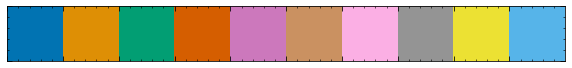

In [5]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
sns.palplot(palette_tab10)

In [6]:
color_list = palette_tab10[1:2] +  palette_tab10[2:3] +  palette_tab10[4:5] 

In [7]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [8]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [9]:
h = 0.6774

In [10]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [11]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [12]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [13]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [14]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [15]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [16]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [17]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [18]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [19]:

volume = (boxsize/h)**3

In [20]:
def gen_LF(sfr, bin_edges, data2bin=None):
    if data2bin is None:
        data2bin = sfr
    total = np.sum(10**sfr)
    dbin = bin_edges[1] - bin_edges[0]
    bin_cents = (bin_edges[:-1] + bin_edges[1:]) / 2
    sums_list = np.zeros_like(bin_cents)
    for ibin, bin_left in enumerate(bin_edges[:-1]):
        mask = (data2bin > bin_left) & (data2bin < bin_edges[ibin+1])
        sums_list[ibin] = np.sum(mask)
    ig10 = np.where(sums_list > 10)[0][-1]
    return bin_cents, np.array(sums_list)/(volume*dbin), total, ig10

In [21]:
bin_edges_sfr = np.arange(-3.5, 4, 0.1)
bin_cents, cent_lf, total_cent, ig10_cent = gen_LF(cent_sfrs, bin_edges_sfr)
bin_cents, sat_lf, total_sat, ig10_sat = gen_LF(np.log10(sat_sfrs), bin_edges_sfr)
bin_cents, gal_lf, total_gal, ig10_gal = gen_LF(np.log10(subhalos["SubhaloSFR"]), bin_edges_sfr)
bin_cents, group_lf, total_group, ig10_group = gen_LF(group_sfrs, bin_edges_sfr)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [22]:
dust = -1/2.5

def sfr2L(X): # For Halpha
    V = X - np.log10(4.4 * 10**-42)
    return V

def L2sfr(X): # For Halpha
    V = X + np.log10(4.4 * 10**-42)
    return V

In [27]:
z_tng = 3
fontsize=18

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log10
  """
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:35: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:36: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:40: RuntimeWarning: divide by zero encountered in log10
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:41: RuntimeWarning: divide by zero encountered in log10


>>> output ../figures/sfr_func_w_dust_z=3.pdf


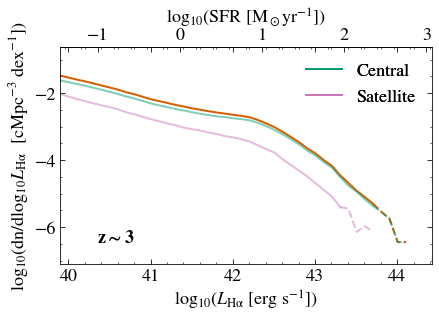

In [29]:

# other
# with dust
fig, ax = plt.subplots()
tng = ax.plot(sfr2L(bin_cents[:ig10_gal+1])+dust, np.log10(gal_lf[:ig10_gal+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[3])
tng = ax.plot(sfr2L(bin_cents[ig10_gal:])+dust, np.log10(gal_lf[ig10_gal:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[3], linestyle="dashed")

#eagle = ax.plot(sfr2L(df_eagles[0]["sfr"][:ig10_eagles[0]+1])+dust, np.log10(df_eagles[0]["phi"][:ig10_eagles[0]+1]), label= f"EAGLE (z = {z_eag})" , linewidth =2, c="purple")
#eagle = ax.plot(sfr2L(df_eagles[0]["sfr"][ig10_eagles[0]:])+dust, np.log10(df_eagles[0]["phi"][ig10_eagles[0]:]), label= f"EAGLE (z = {z_eag})" , linewidth =2, linestyle="dashed", c="purple")
#sobral_int = ax.errorbar(df_sobral["luminosity"]+dust, df_sobral["corr"], c="green", yerr=df_sobral["corr_err"], fmt="o", mfc="none", capsize=5)


ax.set_xlabel(r"log$_{10}$($L_{\rm H\alpha}$ [erg s$^{-1}$])", fontsize=fontsize)
ax.set_ylabel(r"log$_{10}$(dn/dlog$_{10}L_{\rm H\alpha}$  [cMpc$^{−3}$ dex$^{-1}$])", fontsize=fontsize)

# handles1, labels1 = ax.get_legend_handles_labels()
# sobral = ax.errorbar([],[], yerr=1, color="green", fmt="o", mfc="none", capsize=5)
# leg_sim1 = ax.legend(handles1[::2], labels1[::2], columnspacing=1, 
#                  bbox_to_anchor=(0,0.3), loc="lower left", frameon=False, title="Simulations")
# leg_sim1._legend_box.align = "left"

# ax.add_artist(leg_sim1)

# #gruppioni = ax.errorbar(sfr2L(np.log10(df_gruppioni["sfr"])), gruppioni_phi, c="red", yerr=gruppioni_err, fmt="o", mfc="none", capsize=5)
# arnouts, = ax.plot(sfr2L(sfr_arnouts)+dust, phi_arnouts, linestyle="dotted", c="m")

# leg_sob = ax.legend([sobral_int, arnouts], [fr"Sobral+13, H$\alpha$ (z={z_sobral})", fr"Arnouts+05, UV (z={z_arnouts})"], borderaxespad=0.5, loc="lower left", frameon=False, title="Observations")

# leg_sob._legend_box.align = "left"
# ax.add_artist(leg_sob)
ax.set_xlim(39.9,)
ax.set_ylim(-7.1,)

#Cents
tng = ax.plot(sfr2L(bin_cents[:ig10_cent+1])+dust, np.log10(cent_lf[:ig10_cent+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[2], alpha=0.5)
tng = ax.plot(sfr2L(bin_cents[ig10_cent:])+dust, np.log10(cent_lf[ig10_cent:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[2], alpha=0.5, linestyle="dashed")


#Sats
tng = ax.plot(sfr2L(bin_cents[:ig10_sat+1])+dust, np.log10(sat_lf[:ig10_sat+1]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[4], alpha=0.5)
tng = ax.plot(sfr2L(bin_cents[ig10_sat:])+dust, np.log10(sat_lf[ig10_sat:]), label= f"TNG (z = {z_tng})" , linewidth =2, c=palette_tab10[4], alpha=0.5, linestyle="dashed")



cent = Line2D([],[],color=palette_tab10[2], linestyle="solid", label="Central")
sat = Line2D([],[],color=palette_tab10[4], linestyle="solid", label="Satellite")

leg = plt.legend(handles=[cent, sat])
ax.add_artist(leg)


ax2 = ax.secondary_xaxis('top', functions=(L2sfr, sfr2L))
ax2.set_xlabel(r"log$_{10}$(SFR [M$_\odot$yr$^{-1}$])", fontsize=fontsize)

ax.annotate("$\mathbf{z \sim 3}$", (0.1,0.1), xycoords="axes fraction", ha="left", weight="bold")


#idir = "figures"
odir = "../figures"

fout = f"{odir}/sfr_func_w_dust_z={z_tng}.pdf"
plt.savefig(f"{odir}/{fout}", format="pdf", bbox_inches="tight")
print(">>> output "+fout)
plt.show()
plt.close(fig)